# Sentiment analysis with pretrained word vectors

In Chapter 15, Word Embeddings, we discussed how to learn domain-specific word embeddings. Word2vec, and related learning algorithms, produce high-quality word vectors, but require large datasets. Hence, it is common that research groups share word vectors trained on large datasets, similar to the weights for pretrained deep learning models that we encountered in the section on transfer learning in the previous chapter.

We are now going to illustrate how to use pretrained Global Vectors for Word Representation (GloVe) provided by the Stanford NLP group with the IMDB review dataset.

In [31]:
%matplotlib inline

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score

import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU, Embedding, Input
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
gpu_devices = tf.config.experimental.list_physical_devices("GPU")
if gpu_devices:
    print("Using GPU")
    tf.config.experimental.set_memory_growth(gpu_devices[0], True)
else:
    print("Using CPU")

Using CPU


In [3]:
sns.set_style("whitegrid")
np.random.seed(42)

In [4]:
results_path = Path("results", "sentiment_imdb")
if not results_path.exists():
    results_path.mkdir(parents=True)

## Load Reviews

We are going to load the IMDB dataset from the source for manual preprocessing.

Data source: [Stanford IMDB Reviews Dataset](http://ai.stanford.edu/~amaas/data/sentiment/)

Dowload extract, and place the content in a newly created `data` folder so that your directory structure looks as follows:
```
19_recurrent_neural_nets
 |-data
     |-aclimdb
          |-train
              |-neg
              |-pos
              ...
          |-test
          |-imdb.vocab
```

In [5]:
path = Path("data", "aclImdb")

In [6]:
files = path.glob("**/*.txt")
len(list(files))

100006

In [12]:
files = path.glob("*/**/*.txt")
outcomes = set()
data = []
for f in files:
    if f.stem.startswith(("urls_", "imdbEr")):
        continue
    _, _, data_set, outcome = f.parent.as_posix().split("/")
    if outcome == "unsup":
        continue
    data.append([data_set, int(outcome == "pos"), f.read_text(encoding="latin1")])

In [13]:
data = pd.DataFrame(data, columns=["dataset", "label", "review"])

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   dataset  50000 non-null  object
 1   label    50000 non-null  int64 
 2   review   50000 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.1+ MB


In [15]:
train_data = data.loc[data.dataset == "train", ["label", "review"]]
test_data = data.loc[data.dataset == "test", ["label", "review"]]

In [16]:
train_data.label.value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

In [17]:
test_data.label.value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

## Prepare Data

### Tokenizer

Keras provides a tokenizer that we use to convert the text documents to integer-encoded sequences, as shown here:

In [18]:
num_words = 10000
t = Tokenizer(num_words=num_words, lower=True, oov_token=2)
t.fit_on_texts(train_data.review)

In [19]:
vocab_size = len(t.word_index) + 1
vocab_size

88586

In [20]:
train_data_encoded = t.texts_to_sequences(train_data.review)
test_data_encoded = t.texts_to_sequences(test_data.review)

In [21]:
max_length = 100

### Pad Sequences

We also use the pad_sequences function to convert the list of lists (of unequal length) to stacked sets of padded and truncated arrays for both the train and test datasets:

In [22]:
X_train_padded = pad_sequences(
    train_data_encoded, maxlen=max_length, padding="post", truncating="post"
)
y_train = train_data["label"]
X_train_padded.shape

(25000, 100)

In [23]:
X_test_padded = pad_sequences(
    test_data_encoded, maxlen=max_length, padding="post", truncating="post"
)
y_test = test_data["label"]
X_test_padded.shape

(25000, 100)

## Load Embeddings

Assuming we have downloaded and unzipped the GloVe data to the location indicated in the code, we now create a dictionary that maps GloVe tokens to 100-dimensional real-valued vectors, as follows:

In [24]:
# load the whole embedding into memory
glove_path = Path("..", "data", "glove", "glove.6B.100d.txt")
embeddings_index = dict()

for line in glove_path.open(encoding="latin1"):
    values = line.split()
    word = values[0]
    try:
        coefs = np.asarray(values[1:], dtype="float32")
    except:
        continue
    embeddings_index[word] = coefs

In [25]:
print("Loaded {:,d} word vectors.".format(len(embeddings_index)))

Loaded 399,883 word vectors.


There are around 340,000 word vectors that we use to create an embedding matrix that matches the vocabulary so that the RNN model can access embeddings by the token index:

In [26]:
embedding_matrix = np.zeros((vocab_size, 100))
for word, i in t.word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

In [27]:
embedding_matrix.shape

(88586, 100)

## Define Model Architecture

The difference between this and the RNN setup in the previous example is that we are going to pass the embedding matrix to the embedding layer and set it to non-trainable, so that the weights remain fixed during training:

In [28]:
embedding_size = 100

In [35]:
rnn = Sequential(
    [   
        Input(shape=(max_length,)),
        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_size,
            weights=[embedding_matrix],
            trainable=False,
        ),
        GRU(units=32, dropout=0.2, recurrent_dropout=0.2),
        Dense(1, activation="sigmoid"),
    ]
)
rnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 100)       │     8,858,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 32)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,871,497 (33.84 MB)

 Trainable params: 12,897 (50.38 KB)

 Non-trainable params: 8,858,600 (33.79 MB)

In [36]:
rnn.compile(
    loss="binary_crossentropy",
    optimizer="RMSProp",
    metrics=["accuracy", tf.keras.metrics.AUC(name="AUC")],
)

In [37]:
rnn_path = (results_path / "lstm.pretrained.keras").as_posix()

checkpointer = ModelCheckpoint(
    filepath=rnn_path, verbose=1, monitor="val_AUC", mode="max", save_best_only=True
)

In [38]:
early_stopping = EarlyStopping(
    monitor="val_AUC", patience=5, mode="max", restore_best_weights=True
)

In [39]:
training = rnn.fit(
    X_train_padded,
    y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_test_padded, y_test),
    callbacks=[early_stopping, checkpointer],
    verbose=1,
)

Epoch 1/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - AUC: 0.5562 - accuracy: 0.5362 - loss: 0.6866
Epoch 1: val_AUC improved from -inf to 0.81887, saving model to results/sentiment_imdb/lstm.pretrained.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - AUC: 0.5563 - accuracy: 0.5363 - loss: 0.6866 - val_AUC: 0.8189 - val_accuracy: 0.7439 - val_loss: 0.5278
Epoch 2/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - AUC: 0.7986 - accuracy: 0.7346 - loss: 0.5463
Epoch 2: val_AUC improved from 0.81887 to 0.86495, saving model to results/sentiment_imdb/lstm.pretrained.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - AUC: 0.7986 - accuracy: 0.7347 - loss: 0.5462 - val_AUC: 0.8649 - val_accuracy: 0.7792 - val_loss: 0.4620
Epoch 3/100
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - AUC: 0.8524 - accuracy: 0.7741 - loss: 0.4770
Epoch 3: val_AUC improved from 0.86495 to 0.88073, saving model to results/sentiment_imdb/lstm.pretrained.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - AUC: 0.8524 - 

In [40]:
y_score = rnn.predict(X_test_padded)
roc_auc_score(y_score=y_score.squeeze(), y_true=y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step


0.913113264

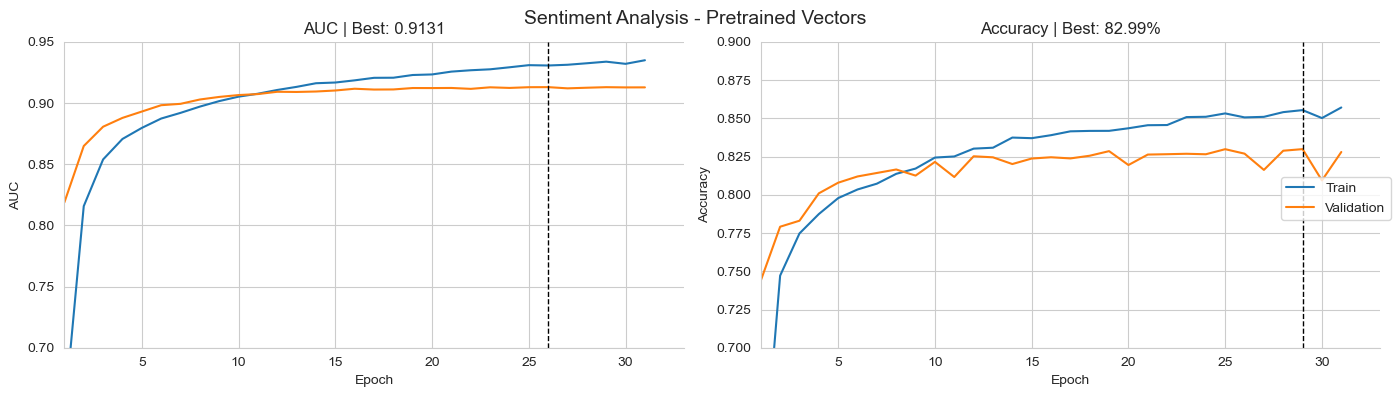

In [41]:
df = pd.DataFrame(training.history)
best_auc = df.val_AUC.max()
best_acc = df.val_accuracy.max()

fig, axes = plt.subplots(ncols=2, figsize=(14, 4))
df.index = df.index.to_series().add(1)
df[["AUC", "val_AUC"]].plot(
    ax=axes[0],
    title=f"AUC | Best: {best_auc:.4f}",
    legend=False,
    xlim=(1, 33),
    ylim=(0.7, 0.95),
)

axes[0].axvline(df.val_AUC.idxmax(), ls="--", lw=1, c="k")
df[["accuracy", "val_accuracy"]].plot(
    ax=axes[1],
    title=f"Accuracy | Best: {best_acc:.2%}",
    legend=False,
    xlim=(1, 33),
    ylim=(0.7, 0.9),
)
axes[1].axvline(df.val_accuracy.idxmax(), ls="--", lw=1, c="k")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("AUC")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
fig.suptitle("Sentiment Analysis - Pretrained Vectors", fontsize=14)
fig.legend(["Train", "Validation"], loc="center right")

sns.despine()
fig.tight_layout()
fig.subplots_adjust(top=0.9)
fig.savefig(results_path / "imdb_pretrained", dpi=300);